In [2]:
import numpy as np
import pandas as pd

In [3]:
import numpy as np
import pandas as pd

csv_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'

df = pd.read_csv(csv_url)

display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
x = df.drop('species', axis=1)
y = df['species']

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9666666666666667

In [10]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[11,  0,  0],
       [ 0,  7,  1],
       [ 0,  0, 11]])

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression Model
log_model = LogisticRegression(max_iter=200) # Corrected typo and variable name
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)

log_acc = accuracy_score(y_test, log_pred) # Corrected variable name

# K-Nearest Neighbors Model
knn_model = KNeighborsClassifier(n_neighbors=5) # Corrected syntax for assignment
knn_model.fit(x_train, y_train)
knn_pred = knn_model.predict(x_test)

knn_acc = accuracy_score(y_test, knn_pred) # Corrected variable name

print("Logistic Regression Accuracy:", log_acc)
print("KNN Accuracy:", knn_acc)

Logistic Regression Accuracy: 0.9666666666666667
KNN Accuracy: 0.9666666666666667


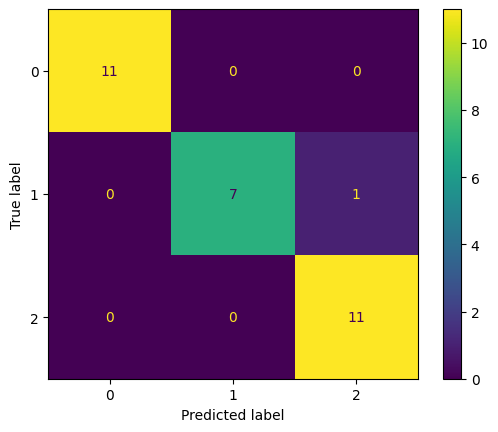

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.show()

In [20]:
x_vis = df[['petal_length','petal_width']]
# x_vis = y # This line was overwriting the feature data, hence commented out

In [21]:
from sklearn.neighbors import KNeighborsClassifier
model_vis = KNeighborsClassifier(n_neighbors=5)
x_vis = df[['petal_length','petal_width']]
y_vis = y
model_vis.fit(x_vis, y_vis)

KNeighborsClassifier()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


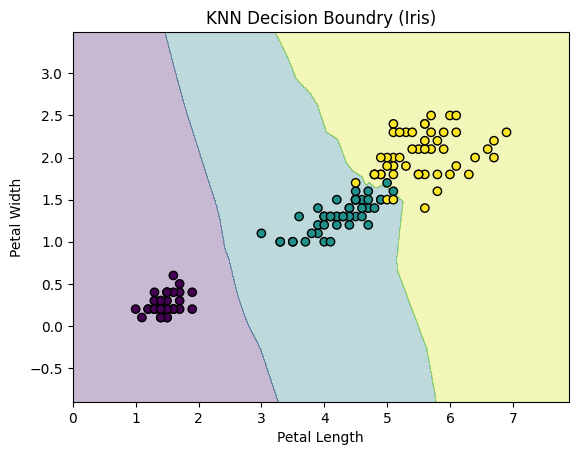

In [23]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = x_vis.iloc[:, 0].min() - 1, x_vis.iloc[:, 0].max() + 1
y_min, y_max = x_vis.iloc[:, 1].min() - 1, x_vis.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

plt.contourf(xx, yy, z, alpha=0.3)
plt.scatter(x_vis.iloc[:, 0], x_vis.iloc[:, 1], c=y_vis, edgecolor='k')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Decision Boundry (Iris)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


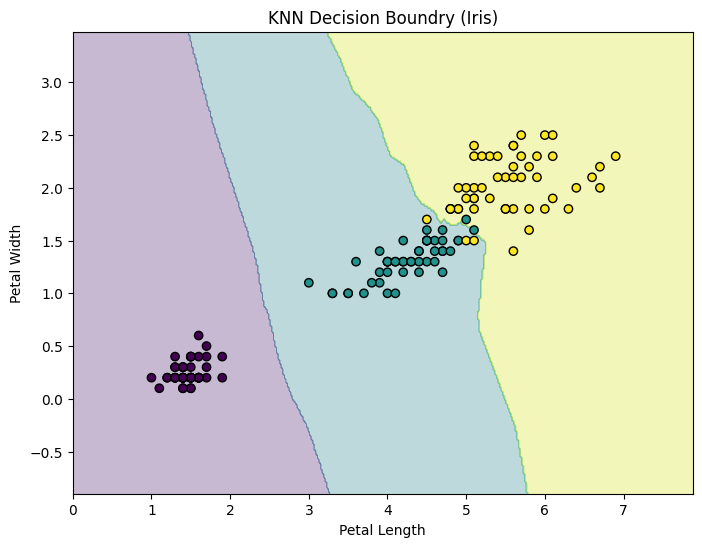

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = x_vis.iloc[:, 0].min() - 1, x_vis.iloc[:, 0].max() + 1
y_min, y_max = x_vis.iloc[:, 1].min() - 1, x_vis.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, z, alpha=0.3)
plt.scatter(x_vis.iloc[:, 0], x_vis.iloc[:, 1], c=y_vis, edgecolor='k')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Decision Boundry (Iris)")
plt.show()